In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
#COMPARAR LOS SIGUIENTES MODELOS
from sklearn.tree import DecisionTreeClassifier #(ÁRBOL DE DECISIÓN)
from sklearn.neighbors import KNeighborsClassifier #(K VECINOS CERCANOS)

In [ ]:
mnist= fetch_openml('Fashion-MNIST', version=1, as_frame= False) #Fashion-MNIST: prendas de ropa

programa multiclase
entropia del desorden

2 clasificadores con el mismo dataset

In [ ]:
x= mnist.data/255.0 #normalizamos los datos (entre 0 y 1)
y= mnist.target

In [ ]:
print(mnist.data.shape) #FORMA DE LOS DATOS
print(mnist.categories)   #ETIQUETAS
print(len(mnist.categories))   #CANTIDAD DE CATEGORIAS
print(x[0].shape)   #FORMA NATURAL DE UNA ETIQUETA
print(x[0].reshape(28,28).shape)  #FOPRMA MODIFICADA DE LA MUESTRA 2D (28,28)

(70000, 784)
{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}
1
(784,)
(28, 28)


In [ ]:
model = DecisionTreeClassifier()  # Árbol de decisión
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
model.fit(x_train, y_train)  # Entrenamos el model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred= model.predict(x_test)
print('PREDICCIONES DEL MODELO')
print(y_pred[:20]) #mostramos las primeras 20 predicciones
print('ETIQUETAS REALES')
print(y_test[:20]) #mostramos las primeras 20 etiquetas reales

PREDICCIONES DEL MODELO
['6' '0' '4' '8' '4' '7' '4' '6' '6' '7' '3' '0' '1' '7' '7' '4' '7' '4'
 '7' '4']
ETIQUETAS REALES
['6' '3' '4' '8' '4' '7' '4' '3' '6' '7' '3' '0' '1' '7' '7' '4' '7' '4'
 '7' '4']


In [ ]:
print('Métricas del modelo')
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Métricas del modelo
0.7932142857142858
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1400
           1       0.94      0.95      0.94      1400
           2       0.67      0.69      0.68      1400
           3       0.80      0.79      0.79      1400
           4       0.66      0.65      0.65      1400
           5       0.89      0.90      0.90      1400
           6       0.55      0.55      0.55      1400
           7       0.88      0.86      0.87      1400
           8       0.91      0.90      0.90      1400
           9       0.90      0.91      0.90      1400

    accuracy                           0.79     14000
   macro avg       0.79      0.79      0.79     14000
weighted avg       0.79      0.79      0.79     14000



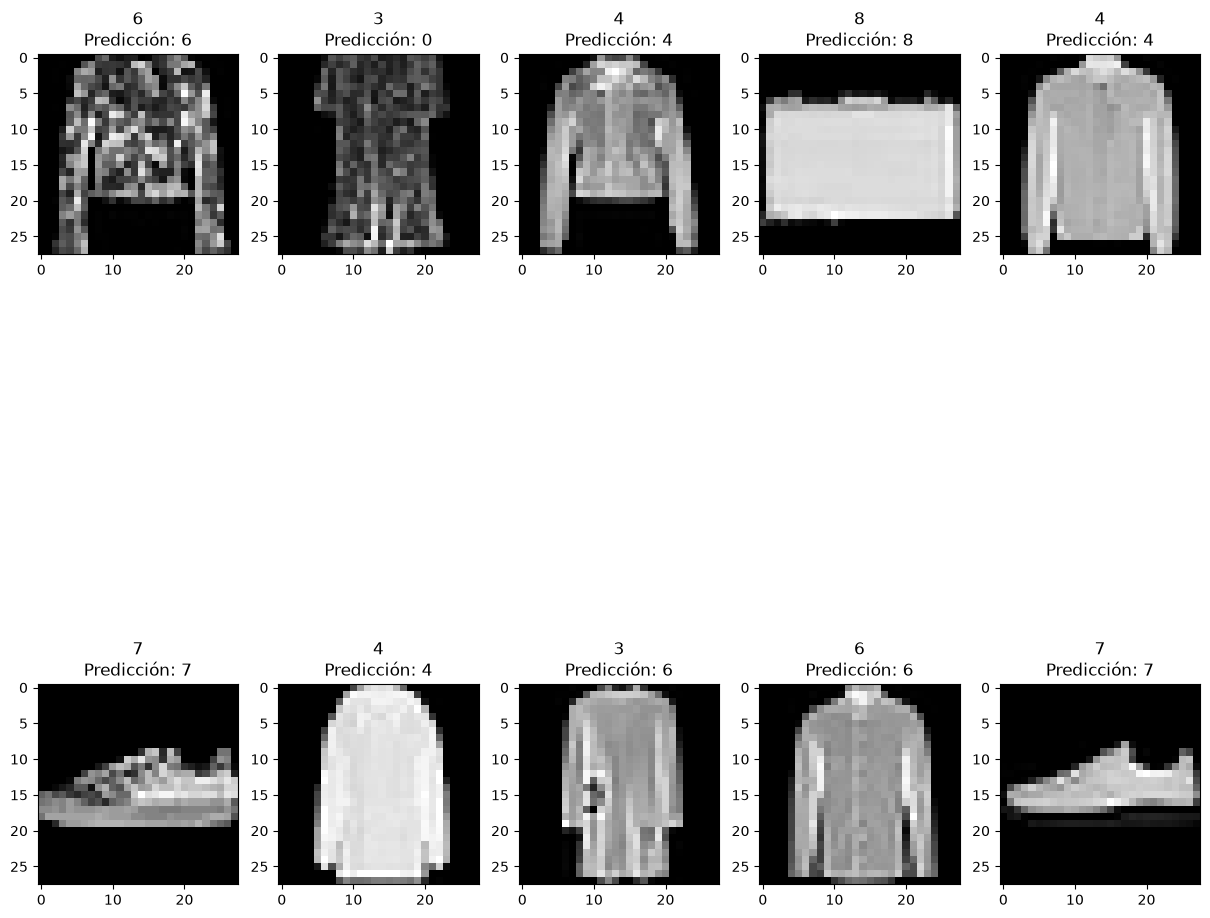

In [ ]:
plt.figure(figsize=(15, 15))
for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(y_test[i]+"\nPredicción: "+y_pred[i])

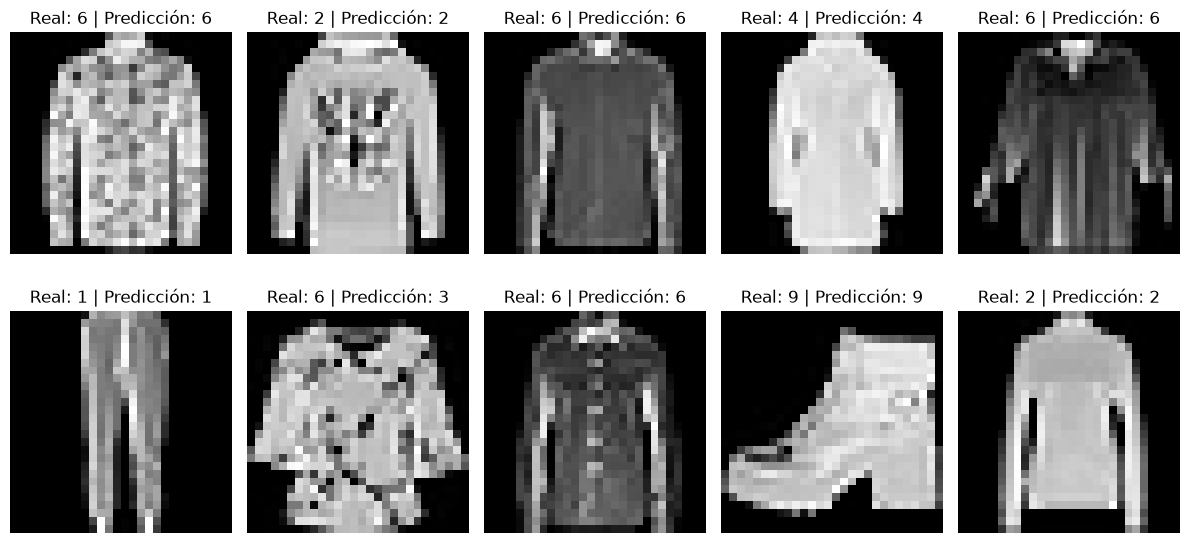

In [ ]:
indices = np.random.choice(len(x_test), size=10, replace=False)
predicciones = model.predict(x_test[indices])

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for ax, indice, prediccion in zip(axes.ravel(), indices, predicciones):
    ax.imshow(x_test[indice].reshape(28, 28), cmap="gray")
    ax.set_title(f"Real: {y_test[indice]} | Predicción: {prediccion}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#controlar el indice con valor
idx=4
muestra= x_test[idx].reshape(1,-1)
print(muestra.shape)
print("prediccion del modelo",y_pred[idx])
print("etiqueta real",y_test[idx])

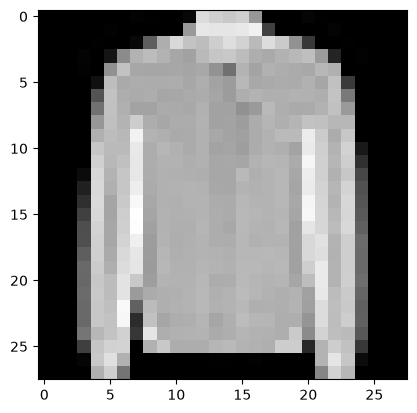

In [ ]:
plt.imshow(muestra.reshape(28,28), cmap='gray')

MODELO CON VECINOS CERCANOS

In [ ]:
model2 = KNeighborsClassifier()
model2.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pred2= model2.predict(x_test)
print('PREDICCIONES DEL MODELO')
print(y_pred2[:20]) #mostramos las primeras 20 predicciones
print('ETIQUETAS REALES')
print(y_test[:20]) #mostramos las primeras 20 etiquetas reales

PREDICCIONES DEL MODELO
['2' '6' '4' '8' '4' '7' '4' '6' '6' '7' '3' '0' '1' '7' '7' '6' '7' '4'
 '7' '4']
ETIQUETAS REALES
['6' '3' '4' '8' '4' '7' '4' '3' '6' '7' '3' '0' '1' '7' '7' '4' '7' '4'
 '7' '4']


In [ ]:
print('Métricas del modelo')
print(accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Métricas del modelo
0.8525714285714285
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      1400
           1       0.99      0.96      0.98      1400
           2       0.72      0.81      0.76      1400
           3       0.88      0.86      0.87      1400
           4       0.77      0.76      0.77      1400
           5       0.99      0.84      0.91      1400
           6       0.66      0.56      0.61      1400
           7       0.89      0.94      0.91      1400
           8       0.98      0.95      0.96      1400
           9       0.89      0.97      0.93      1400

    accuracy                           0.85     14000
   macro avg       0.85      0.85      0.85     14000
weighted avg       0.85      0.85      0.85     14000



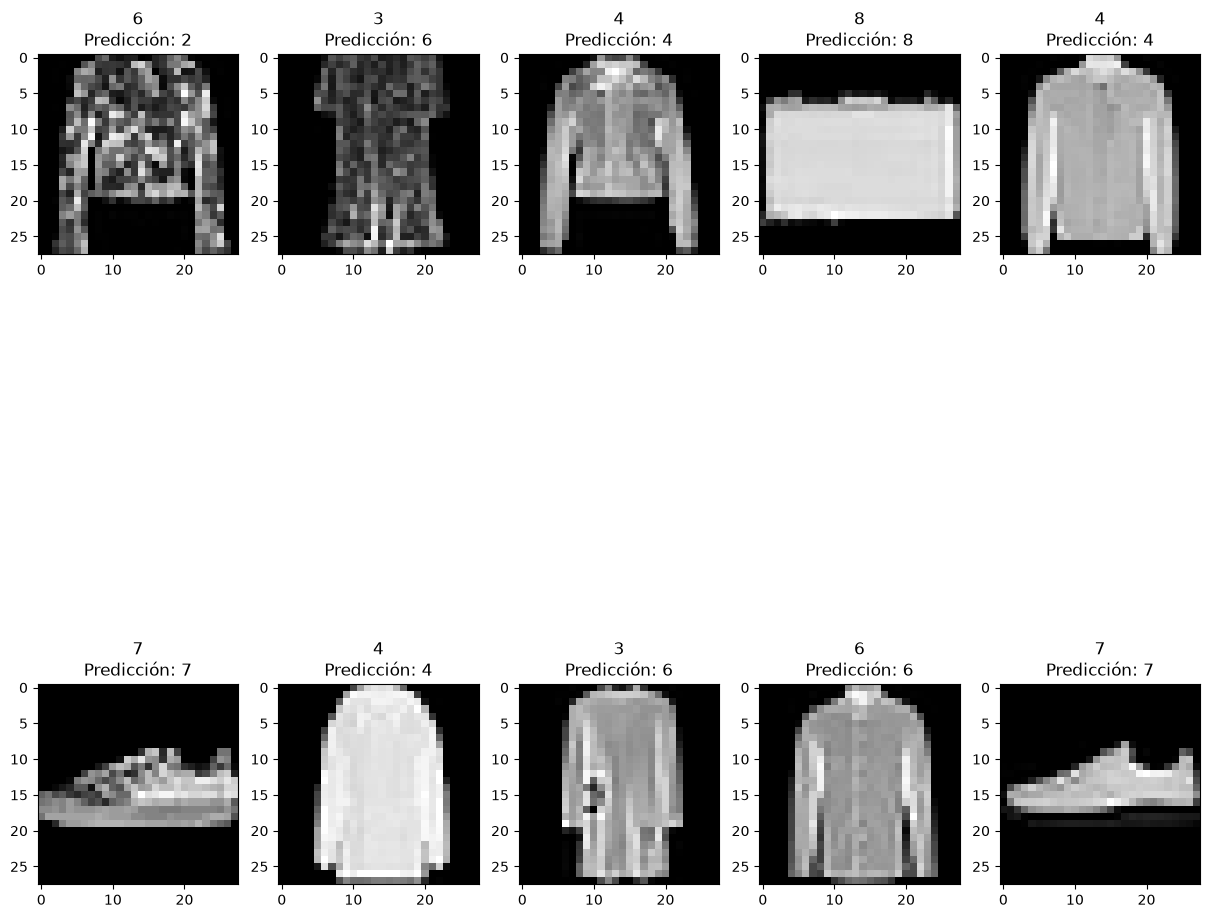

In [ ]:
plt.figure(figsize=(15, 15))
for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(y_test[i]+"\nPredicción: "+y_pred2[i])

In [ ]:
idx=4
muestra= x_test[idx].reshape(1,-1)
print(muestra.shape)
print("prediccion del modelo",y_pred2[idx])
print("etiqueta real",y_test[idx])

(1, 784)
prediccion del modelo 4
etiqueta real 4


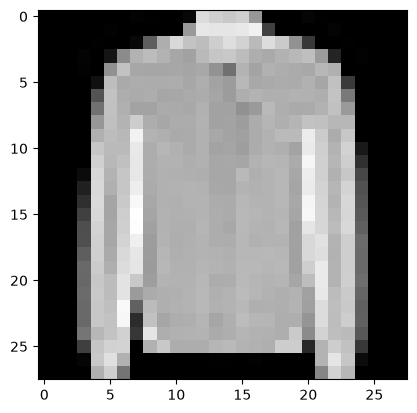

In [ ]:
plt.imshow(muestra.reshape(28,28), cmap='gray')

COMPARACIÓN DE MODELOS

In [ ]:
acc_arbol = accuracy_score(y_test, y_pred)
acc_knn = accuracy_score(y_test, y_pred2)

print(f"Árbol de decisión: {acc_arbol*100:.2f}%")
print(f"KNN: {acc_knn*100:.2f}%")
print("Mejor modelo:", "KNN" if acc_knn > acc_arbol else "Árbol de decisión")

plt.bar(['Árbol de decisión', 'KNN'], [acc_arbol, acc_knn], color=['orange', 'steelblue'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Comparación de modelos con Fashion-MNIST')
plt.show()